In [18]:
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt
import ecos


# Problem 1

$$\min e^{x_1 - 1} + e^{-x_1 + 1} + e^{x_2-2} + e^{-x_2 +2 } + e^{-x_3 + 3} + (x_1 - 2x_2 +5x_3)^4$$

In [49]:
# Write a code in CVX to find the global minimum x*

x1 = cp.Variable()
x2 = cp.Variable()
x3 = cp.Variable()

objective = cp.Minimize(
    cp.exp(x1-1) + cp.exp(-x1+1) +
    cp.exp(x2-2) + cp.exp(-x2+2) +
    cp.exp(x3-3) + cp.exp(-x3+3) +
    cp.power((x1 - 2*x2 + 5*x3), 4)
)

problem = cp.Problem(objective)
problem.solve()

x1_cp = x1.value
x2_cp = x2.value
x3_cp = x3.value

print(f"CVXPY Solution: x1 = {x1_cp}, x2 = {x2_cp}, x3 = {x3_cp}")

CVXPY Solution: x1 = 0.4573801355825401, x2 = 2.976508302346172, x3 = 1.2307154858979108


In [96]:
# Then, write a code that implements the Gradient method with your choice of the backtracking parameters. 

x1 = 1
x2 = 1
x3 = 1

arr_g = []
arr_g.append([x1, x2, x3])


def f(x):
    x1, x2, x3 = x
    return (np.exp(x1-1) + np.exp(-x1+1) + np.exp(x2-2) + np.exp(-x2+2) + np.exp(x3-3) + np.exp(-x3+3) + (x1 - 2*x2 + 5*x3)**4)


def calc_gradient(x):
    x1, x2, x3 = x

    dx1 = np.exp(x1-1) - np.exp(-x1+1) + 4 * (x1 - 2*x2 + 5*x3)**3 * 1
    dx2 = np.exp(x2-2) - np.exp(-x2+2) + 4 * (x1 - 2*x2 + 5*x3)**3 * (-2)
    dx3 = np.exp(x3-3) - np.exp(-x3+3) + 4 * (x1 - 2*x2 + 5*x3)**3 * (5)
    return np.array([dx1, dx2, dx3])


def step_size():
    # backtracking line search 
    alpha = 0.05  # Step size reduction factor
    beta = 0.1  # Inital t

    while f(arr_g[-1] - beta * calc_gradient(arr_g[-1])) >= f(arr_g[-1]):
        beta *= alpha

    return beta


for i in range(51):
    gradient = calc_gradient(arr_g[-1])
    t = step_size()
    x_new = arr_g[-1] - t * gradient
    arr_g.append(x_new)

xstar = arr_g[-1]
print(f"Gradient Descent Solution: x1 = {xstar[0]}, x2 = {xstar[1]}, x3 = {xstar[2]}")

Gradient Descent Solution: x1 = 0.4566138962977194, x2 = 2.972826937170818, x3 = 1.2294275351541832


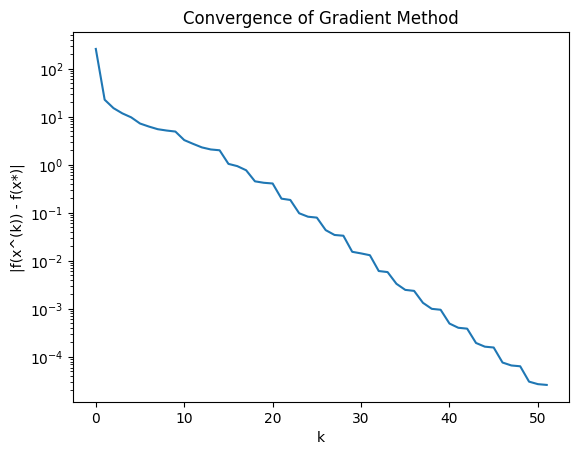

In [97]:
# Draw |f(x(k)) − f(x∗)| verses k for k = 0, 1, 2, . . . , 50 on alog-linear plot. 
# Show the trajectory of the points x(0), x(1), ..., x(50) in the 3-dimensional (x1, x2, x3) plane.

f_vals = np.array([f(x) for x in arr_g])

x_star = np.array([x1_cp, x2_cp, x3_cp])
f_star = f(x_star)

errors = np.abs(f_vals - f_star)
k = np.arange(len(arr_g))

plt.semilogy(k, errors)

plt.xlabel("k")
plt.ylabel("|f(x^(k)) - f(x*)|")
plt.title("Convergence of Gradient Method")

plt.show()

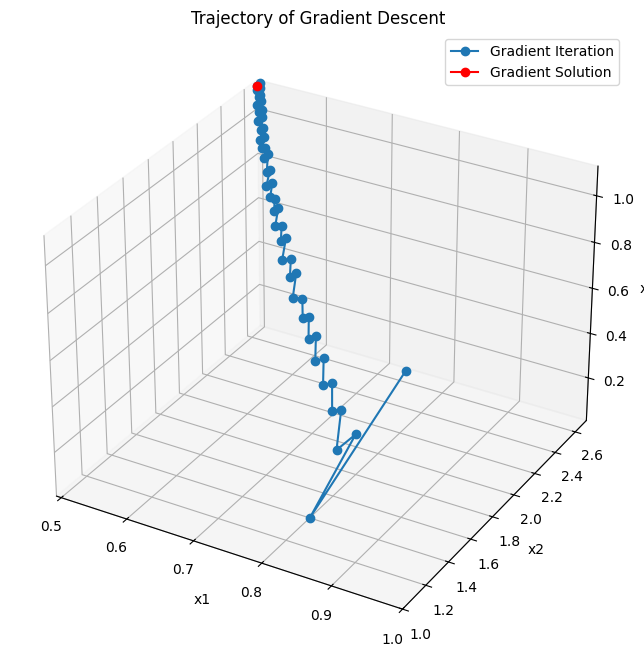

In [91]:
fig = plt.figure(figsize=(8, 8))

ax = fig.add_subplot(111, projection="3d")

arr_g = np.array(arr_g)

ax.plot(arr_g[:,0], arr_g[:,1], arr_g[:,2], marker="o", label = "Gradient Iteration")

ax.plot(*xstar, marker="o", color="red", label = "Gradient Solution")

ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_zlabel("x3")
ax.set_title("Trajectory of Gradient Descent")

ax.set_xlim(min(arr_g[:,0]), max(arr_g[:,0]) )
ax.set_ylim(min(arr_g[:,1]), max(arr_g[:,1]) )
ax.set_zlim(min(arr_g[:,2]), max(arr_g[:,2]) )
ax.legend()

plt.show()

\newpage

# Problem 2
Redo the previous problem with Newton’s method.

In [ ]:
x_0 = [1,1,1]
arr_n = np.array(x_0)

alpha = 0.5
beta = 0.1

for i in range(50):
    hessian = np.diag([
        np.exp(x[0]-1) + np.exp(-x[0]+1),
        np.exp(x[1]-2) + np.exp(-x[1]+2),
        np.exp(x[2]-3) + np.exp(-x[2]+3)
    ])
    gradient = np.array([
        np.exp(x[0]-1) - np.exp(-x[0]+1) + 1,
        np.exp(x[1]-2) - np.exp(-x[1]+2) - 2,
        np.exp(x[2]-3) - np.exp(-x[2]+3) + 5
    ])
    delta = np.linalg.solve(hessian, gradient)
    
    t = 1
    # backtracking line search
    while f(x - t * delta) > f(x) - alpha * t * gradient @ delta:
        t *= beta  # shrink step size

    # update x after line search
    x = x - t * delta
    arr_n.append(x.copy())

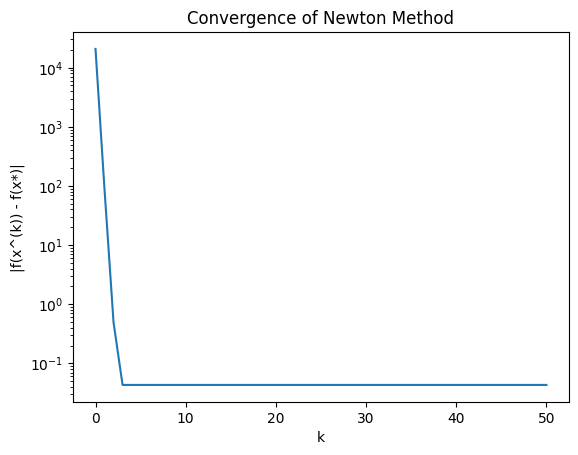

In [56]:
f_vals = np.array([f(x) for x in arr_n])

x_star = np.array([x1_cp, x2_cp, x3_cp])
f_star = f(x_star)

errors = np.abs(f_vals - f_star)
k = np.arange(len(arr_n))

plt.semilogy(k, errors)

plt.xlabel("k")
plt.ylabel("|f(x^(k)) - f(x*)|")
plt.title("Convergence of Newton Method")

plt.show()

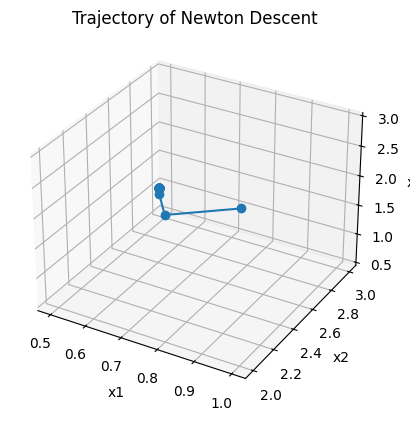

In [57]:
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

arr_n = np.array(arr_n)

ax.plot(arr_n[:,0], arr_n[:,1], arr_n[:,2], marker="o")

ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_zlabel("x3")
ax.set_title("Trajectory of Newton Descent")

plt.show()

$$ \min_{x \in \mathbb{R}^n} -\sum_{i=1}^n log(1-x_i^2) - \sum_{i=1}^n log(4 + a_i^Tx) $$

In [2]:
# 3 CVX
np.random.seed(0)

n = 2000

A = np.random.rand(n, n)


In [3]:
# 3 CVX, flipped the problem to become maximization
eps = 1e-4

x = cp.Variable(n)

term1 = cp.sum(cp.log1p(-x) + cp.log1p(x))
term2 = cp.sum(cp.log(4 + A @ x))

objective = cp.Maximize(term1 + term2)


In [4]:
constraints = [x >= -1 + 1e-6, x <= 1 - 1e-6]

In [5]:
# 3 CVX
problem = cp.Problem(objective, constraints)

KeyboardInterrupt: 

In [ ]:
#3 ECOS Solver

problem.solve(
    solver=cp.ECOS,
    abstol=1e-3,
    reltol=1e-3,
    feastol=1e-3,
    max_iters=200,
    verbose=True
)

(CVXPY) Mar 11 03:33:22 PM: Your problem has 2000 variables, 4000 constraints, and 0 parameters.
(CVXPY) Mar 11 03:33:22 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Mar 11 03:33:22 PM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Mar 11 03:33:22 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Mar 11 03:33:22 PM: Your problem is compiled with the CPP canonicalization backend.
(CVXPY) Mar 11 03:33:22 PM: Compiling problem (target solver=ECOS).
(CVXPY) Mar 11 03:33:22 PM: Reduction chain: FlipObjective -> Dcp2Cone -> CvxAttr2Constr -> ConeMatrixStuffing -> ECOS
(CVXPY) Mar 11 03:33:22 PM: Applying reduction FlipObjective
(CVXPY) Mar 11 03:33:22 PM: Applying reduction Dcp2Cone
(CVXPY) Mar 11 03:33:22 PM: Applying reduction CvxAttr2Constr
(CVXPY) Mar 11 03:33:22 PM: Applying reduction ConeMatrixStuffing


                                     CVXPY                                     
                                     v1.8.1                                    
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------


(CVXPY) Mar 11 03:33:25 PM: Applying reduction ECOS
(CVXPY) Mar 11 03:33:27 PM: Finished problem compilation (took 4.681e+00 seconds).
(CVXPY) Mar 11 03:33:27 PM: Invoking solver ECOS  to obtain a solution.


-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------


(CVXPY) Mar 11 03:39:56 PM: Problem status: optimal
(CVXPY) Mar 11 03:39:56 PM: Optimal value: 1.192e+04
(CVXPY) Mar 11 03:39:56 PM: Compilation took 4.681e+00 seconds
(CVXPY) Mar 11 03:39:56 PM: Solver (including time spent in interface) took 3.894e+02 seconds


-------------------------------------------------------------------------------
                                    Summary                                    
-------------------------------------------------------------------------------


np.float64(11919.687668790282)

In [ ]:
# # Access the specific ECOS iteration count
# if problem.solver_stats.solver_name == cp.ECOS:
#     # ECOS stores iteration count under 'iter' in its info dict
#     num_iters = problem.solver_stats.extra_stats['info']['iter']
#     print(f"ECOS converged in {num_iters} iterations.")

ECOS converged in 25 iterations.


In [6]:
# SCS Solver

problem.solve(
    solver=cp.SCS,
    eps=1e-3,        # convergence tolerance (replaces abstol/reltol/feastol)
    max_iters=5000,  # SCS often needs more iterations than ECOS
    verbose=True
)

(CVXPY) Mar 11 04:07:57 PM: Your problem has 2000 variables, 4000 constraints, and 0 parameters.
(CVXPY) Mar 11 04:07:57 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Mar 11 04:07:57 PM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Mar 11 04:07:57 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Mar 11 04:07:57 PM: Your problem is compiled with the CPP canonicalization backend.
(CVXPY) Mar 11 04:07:57 PM: Compiling problem (target solver=SCS).
(CVXPY) Mar 11 04:07:57 PM: Reduction chain: FlipObjective -> Dcp2Cone -> CvxAttr2Constr -> ConeMatrixStuffing -> SCS
(CVXPY) Mar 11 04:07:57 PM: Applying reduction FlipObjective
(CVXPY) Mar 11 04:07:57 PM: Applying reduction Dcp2Cone
(CVXPY) Mar 11 04:07:57 PM: Applying reduction CvxAttr2Constr
(CVXPY) Mar 11 04:07:57 PM: Applying reduction ConeMatrixStuffing


                                     CVXPY                                     
                                     v1.8.1                                    
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------


(CVXPY) Mar 11 04:08:00 PM: Applying reduction SCS
(CVXPY) Mar 11 04:08:01 PM: Finished problem compilation (took 4.246e+00 seconds).
(CVXPY) Mar 11 04:08:01 PM: Invoking solver SCS  to obtain a solution.


-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------
------------------------------------------------------------------
	       SCS v3.2.11 - Splitting Conic Solver
	(c) Brendan O'Donoghue, Stanford University, 2012
------------------------------------------------------------------
problem:  variables n: 8000, constraints m: 22000
cones: 	  l: linear vars: 4000
	  e: exp vars: 18000, dual exp vars: 0
settings: eps_abs: 1.0e-03, eps_rel: 1.0e-03, eps_infeas: 1.0e-07
	  alpha: 1.50, scale: 1.00e-01, adaptive_scale: 1
	  max_iters: 5000, normalize: 1, rho_x: 1.00e-06
	  acceleration_lookback: 10, acceleration_interval: 10
lin-sys:  sparse-direct-amd-qdldl
	  nnz(A): 4014000, nnz(P): 0
------------------------------------------------------------------
 iter | pri res | dua res |   gap   |   obj   |  scale 

(CVXPY) Mar 11 04:08:53 PM: Problem status: optimal
(CVXPY) Mar 11 04:08:53 PM: Optimal value: 1.182e+04
(CVXPY) Mar 11 04:08:53 PM: Compilation took 4.246e+00 seconds
(CVXPY) Mar 11 04:08:53 PM: Solver (including time spent in interface) took 5.217e+01 seconds


   325| 1.90e-01  1.42e-03  3.81e-02 -1.20e+04  2.37e-04  5.21e+01 
------------------------------------------------------------------
status:  solved
timings: total: 5.21e+01s = setup: 1.46e+01s + solve: 3.74e+01s
	 lin-sys: 8.29e+00s, cones: 1.15e+00s, accel: 1.07e-01s
------------------------------------------------------------------
objective = -12040.503980
------------------------------------------------------------------
-------------------------------------------------------------------------------
                                    Summary                                    
-------------------------------------------------------------------------------


np.float64(11818.638355712175)

In [7]:
# 3 CVX
x_star = x.value

if problem.status == cp.OPTIMAL:
    # 1. CVXPY Status
    print(f"Status: {problem.status}")
    
    # 2. Optimal Value f(x*)
    # Note: problem.value reflects the Maximization. 
    # If your original problem was a minimization, use -problem.value
    print(f"Optimal Value f(x*): {-problem.value}")
    
    # 3. Norm of x*
    x_norm = np.linalg.norm(x.value)
    print(f"Norm of x* (||x||_2): {x_norm}")
    
    # 4. Iteration Stopped
    # Using the 'info' dict which is standard for SCS in CVXPY
    iters = problem.solver_stats.extra_stats['info']['iter']
    print(f"Iteration stopped at: {iters}")

else:
    print(f"Solver was not successful. Status: {problem.status}")

Status: optimal
Optimal Value f(x*): -11818.638355712175
Norm of x* (||x||_2): 20.911371680590968
Iteration stopped at: 325


In [ ]:
# 3 Newton's 
# solution with fixed alpha and beta i randomly chose

np.random.seed(0)

n = 2000

A = np.random.rand(n, n)

x = np.zeros(n)

alpha = 0.01
beta = 0.5

def f(x):
    term1 = -np.sum(np.log(1 - x**2))
    term2 = -np.sum(np.log(4 + A @ x))
    return term1 + term2

def grad(x):
    g1 = 2*x/(1 - x**2)
    g2 = A.T @ (1/(4 + A @ x))
    return g1 - g2

def hess(x):
    diag1 = 2*(1 + x**2)/(1 - x**2)**2
    H1 = np.diag(diag1)

    d = 1/(4 + A @ x)**2
    H2 = A.T @ (d[:,None] * A)

    return H1 + H2

max_iter = 100

x_vals = [x.copy()]
f_vals = [f(x)]

for k in range(max_iter):

    g = grad(x)
    H = hess(x)

    delta = -np.linalg.solve(H, g)

    t = 1

    while f(x + t*delta) > f(x) + alpha*t*(g @ delta):
        t *= beta

    x = x + t*delta

    x_vals.append(x.copy())
    f_vals.append(f(x))

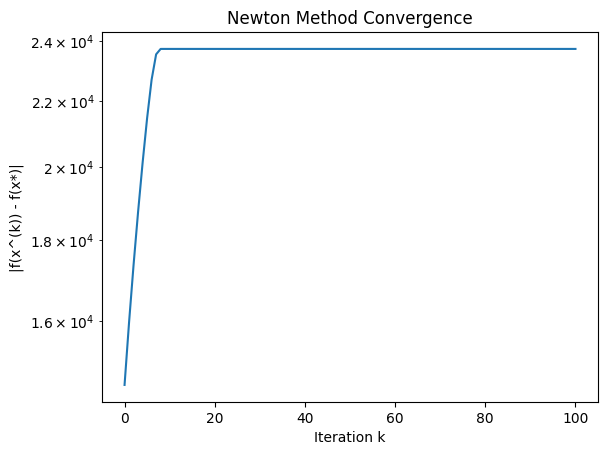

In [9]:
# plot
f_star = problem.value

errors = np.abs(np.array(f_vals) - f_star)

for i in range(100):
    hessian = [[np.exp(x1-1) + np.exp(-x1+1), 0, 0], 
           [0, np.exp(x2-2) + np.exp(-x2+2), 0], 
           [0, 0, np.exp(x3-3) + np.exp(-x3+3)]]
    gradient = [x1 - t * (np.exp(x1-1) - np.exp(-x1+1) + 1), 
                x2 - t * (np.exp(x2-2) - np.exp(-x2+2) - 2), 
                x3 - t * (np.exp(x3-3) - np.exp(-x3+3) + 5)]
    x_new = [x1, x2, x3] - t * (np.linalg.inv(hessian) @ gradient)
    arr_n.append(x_new)
    x1, x2, x3 = x_new[0], x_new[1], x_new[2]

alpha=0.01, beta=0.1 => f=-743.867105
alpha=0.01, beta=0.3 => f=-743.867105
alpha=0.01, beta=0.5 => f=-743.867105
alpha=0.01, beta=0.8 => f=-743.867105
alpha=0.1, beta=0.1 => f=-743.867105
alpha=0.1, beta=0.3 => f=-743.867105
alpha=0.1, beta=0.5 => f=-743.867105
alpha=0.1, beta=0.8 => f=-743.867105
alpha=0.25, beta=0.1 => f=-743.867105
alpha=0.25, beta=0.3 => f=-743.867105
alpha=0.25, beta=0.5 => f=-743.867105
alpha=0.25, beta=0.8 => f=-743.867105
alpha=0.4, beta=0.1 => f=-743.867105
alpha=0.4, beta=0.3 => f=-743.867105
alpha=0.4, beta=0.5 => f=-743.867105
alpha=0.4, beta=0.8 => f=-743.867105

Best (alpha, beta) = (0.01, 0.1)


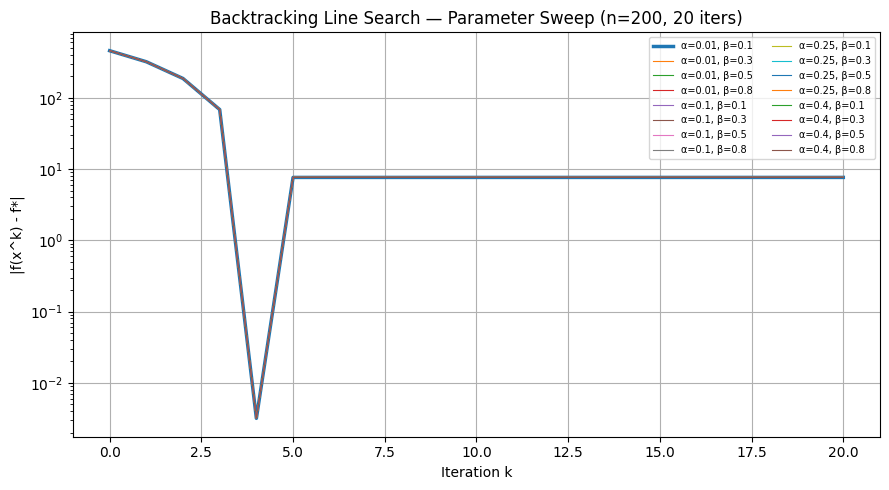

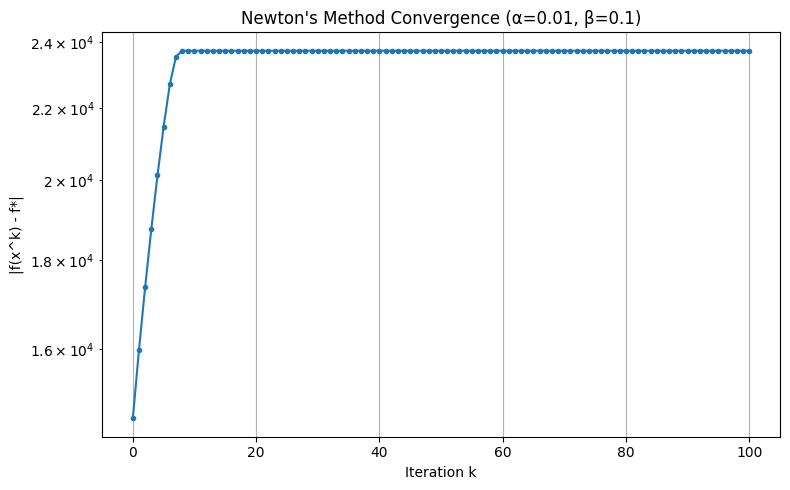


Optimal value (Newton): -11919.687849
Final gap             : 2.37e+04
||x_newton - x*||     : 4.85e+00


In [11]:
# solution optimizing both alpha and beta

np.random.seed(0)
n = 2000
A = np.random.rand(n, n)

# ── Assume these are already defined from your CVX solution ───────────────────
# x_star = x.value
# f_star = -problem.value

# ── Objective, gradient, Hessian ──────────────────────────────────────────────
def f(x, A_mat=None):
    if A_mat is None:
        A_mat = A
    v1 = 1 - x**2
    v2 = 4 + A_mat @ x
    if np.any(v1 <= 0) or np.any(v2 <= 0):
        return np.inf
    return -np.sum(np.log(v1)) - np.sum(np.log(v2))

def grad(x, A_mat=None):
    if A_mat is None:
        A_mat = A
    g1 = 2*x / (1 - x**2)
    g2 = A_mat.T @ (1 / (4 + A_mat @ x))
    return g1 - g2

def hess(x, A_mat=None):
    if A_mat is None:
        A_mat = A
    d1 = 2*(1 + x**2) / (1 - x**2)**2
    H = np.diag(d1)
    d2 = 1 / (4 + A_mat @ x)**2
    H += A_mat.T @ (d2[:, None] * A_mat)
    return H

# ── Parameter sweep on small n ─────────────────────────────────────────────────
n_sweep        = 200
A_sweep        = A[:n_sweep, :n_sweep]
max_iter_sweep = 20
max_iter_final = 100

alphas = [0.01, 0.1, 0.25, 0.4]
betas  = [0.1, 0.3, 0.5, 0.8]

# get f* for sweep problem (use first n_sweep entries of x_star as reference)
f_star_sweep = f(x_star[:n_sweep], A_mat=A_sweep)

results = {}

for alpha in alphas:
    for beta in betas:
        x = np.zeros(n_sweep)
        f_hist = [f(x, A_mat=A_sweep)]

        for k in range(max_iter_sweep):
            g = grad(x, A_mat=A_sweep)
            H = hess(x, A_mat=A_sweep)
            delta = np.linalg.solve(H, -g)

            t = 1.0
            while f(x + t * delta, A_mat=A_sweep) > f(x, A_mat=A_sweep) + alpha * t * (g @ delta):
                t *= beta

            x = x + t * delta
            f_hist.append(f(x, A_mat=A_sweep))

        results[(alpha, beta)] = f_hist
        print(f"alpha={alpha}, beta={beta} => f={f_hist[-1]:.6f}")

# ── Best pair ──────────────────────────────────────────────────────────────────
best_pair = min(results, key=lambda k: results[k][-1])
best_alpha, best_beta = best_pair
print(f"\nBest (alpha, beta) = {best_pair}")

# ── Plot sweep ─────────────────────────────────────────────────────────────────
plt.figure(figsize=(9, 5))
for (alpha, beta), f_hist in results.items():
    diffs = np.abs(np.array(f_hist) - f_star_sweep)
    lw = 2.5 if (alpha, beta) == best_pair else 0.8
    plt.semilogy(diffs, label=f"α={alpha}, β={beta}", linewidth=lw)

plt.xlabel("Iteration k")
plt.ylabel("|f(x^k) - f*|")
plt.title(f"Backtracking Line Search — Parameter Sweep (n={n_sweep}, {max_iter_sweep} iters)")
plt.legend(fontsize=7, ncol=2)
plt.grid(True)
plt.tight_layout()
plt.show()

# ── Final Newton solve on full n with best (alpha, beta) ───────────────────────
x = np.zeros(n)
f_vals = [f(x)]

for k in range(max_iter_final):
    g = grad(x)
    H = hess(x)
    delta = np.linalg.solve(H, -g)

    t = 1.0
    while f(x + t * delta) > f(x) + best_alpha * t * (g @ delta):
        t *= best_beta

    x = x + t * delta
    f_vals.append(f(x))

# ── Plot final convergence ─────────────────────────────────────────────────────
diffs = np.abs(np.array(f_vals) - f_star)

plt.figure(figsize=(8, 5))
plt.semilogy(diffs, marker='o', markersize=3)
plt.xlabel("Iteration k")
plt.ylabel("|f(x^k) - f*|")
plt.title(f"Newton's Method Convergence (α={best_alpha}, β={best_beta})")
plt.grid(True)
plt.tight_layout()
plt.show()

x_newton = x.copy()
print(f"\nOptimal value (Newton): {f_vals[-1]:.6f}")
print(f"Final gap             : {np.abs(f_vals[-1] - f_star):.2e}")
print(f"||x_newton - x*||     : {np.linalg.norm(x_newton - x_star):.2e}")